# Experiment 4 — The value of fine personalization

Figure 9 of the paper: three welfare curves and one depth snapshot comparing
the fine monotone design, the two-type centralized design, and the two-type IC menu.

The two clusters have the same centers and masses as Experiment 1.
The chosen snapshot lies inside its patient-exclusion interval. It shows how
fine personalization serves the patient cluster while excluding only a fraction
of impatient customers. The fine design is implementable and beats the coarse
centralized policy; no unrestricted fine-optimum claim is made.


## Queueing model and optimization scope

Independent Poisson arrivals join one server. A served job draws its service
requirement from the **empirical distribution at its assigned depth**, independently
of delay sensitivity. Service requirements are proportional to historical token
cost, with the same common normalization as `DeepSWE_stats.ipynb`; they are not
measured seconds. Service value is the empirical binary success rate. A no-service
assignment has value, service time, and sojourn time zero.

With potential type arrival rates $\lambda_i$, set
$\rho_i=\lambda_i m_i$, $\rho=\sum_i\rho_i$, and
$R=\tfrac12\sum_i\lambda_i E[S_i^2]$. Reject assignments with $\rho\geq1$.
For FCFS, $w_i=m_i+R/(1-\rho)$ for served types. For nonpreemptive priority,

$$w_i=m_i+\frac{R}{(1-H_i)(1-H_i-\rho_i)},$$

where $H_i$ is the load of higher-priority classes. Welfare per unit time is
$W=\sum_i\lambda_i[V(d_i)-\theta_i w_i]$. No monetary cost is subtracted a
second time. These are **exact stationary calculations under the specified
queueing assumptions**, not queue simulations or an exponential approximation.

IC requires sojourn to be nonincreasing in $\theta$, **including excluded types**.
We also construct prices and check every pairwise deviation and the outside option.
The analysis follows the paper's transferable-price formulation; a new restriction
on prices would require re-solving the menu problem.

This notebook is self-contained. Run its cells from top to bottom; only the
saved files in `data/` are required. Calibration, queueing formulas, optimization,
plotting, and numerical checks are included below. No additional local Python
modules or API calls are needed. Snapshot checksums are checked on every run.

### What “optimal” means in this discretization

The population is approximated by 40 equal-mass types. Personalized
designs are optimized by exhaustively enumerating all
$\binom{45}{5}=1,221,759$ **nonincreasing depth assignments** across ascending
delay sensitivities. This includes exclusion of a high-$\theta$ tail.
For each assignment the optimal static nonpreemptive priority order is descending
$\theta_i/m_i$, which here equals descending $\theta_i$.

The result is an exact optimum **within this monotone policy class**, not a
certificate over all $6^{40}$ assignments. The paper's continuum theorem under
exponential/preemptive assumptions does not by itself certify this finite,
empirical, nonpreemptive calculation. Unrestricted one-type deviation checks and
a 20-versus-40-type comparison below are diagnostics, not proofs of a global
optimum or continuum convergence. The common-depth benchmarks are exhaustive over
their six choices. All statements about fine designs below use this explicit scope.

## Load the empirical calibration

All five depths use one common cost-to-time scaling factor. The loader verifies the saved data before computing service values and moments.


In [1]:
from pathlib import Path
from dataclasses import dataclass
from itertools import combinations, product, permutations
import hashlib
import json
import math

import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

# Launch from this folder, Code/, or the repository root.
ROOT = next((p for p in [Path.cwd(), Path.cwd() / 'Case Study DeepSWE',
                       Path.cwd() / 'Code/Case Study DeepSWE']
             if (p / 'data/manifest.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Launch from the notebook folder, Code/, or the repository root.')
RESULTS = ROOT / 'results'  # Figures used in the paper.

LABELS = np.array(['No service', 'low', 'medium', 'high', 'xhigh', 'max'])

COLORS = {'central': '#4c78a8', 'ic': '#e15759', 'joint': '#4c78a8',
          'depth': '#59a14f', 'priority': '#f28e2b', 'neither': '#777777'}


@dataclass
class Calibration:
    values: np.ndarray
    means: np.ndarray
    seconds: np.ndarray
    samples: dict
    scale: float
    provenance: dict


def load_calibration():
    """Recompute Sol's moments from checksum-verified trial-level snapshots."""
    manifest = json.loads((ROOT / 'data/manifest.json').read_text(encoding='utf-8'))
    records = []
    for entry in [manifest, *manifest['supplemental_files']]:
        raw = (ROOT / 'data' / entry['file']).read_bytes()
        if hashlib.sha256(raw).hexdigest() != entry['sha256']:
            raise ValueError(f"Snapshot checksum mismatch: {entry['file']}")
        part = json.loads(raw.decode('utf-8-sig'))
        assert len(part) == entry['record_count']
        records.extend(part)
    records = [r for r in records if r['model'] == 'gpt-5-6-sol']
    assert len(records) == 2260 and len({r['trial_name'] for r in records}) == 2260
    excluded = [r for r in records if not r['included_in_score']]
    assert len(excluded) == 4
    assert all(r['error_category'] == 'verifier_timeout' for r in excluded)
    scale = 1 / np.mean([r['cost_usd'] for r in records])
    values, means, seconds, samples = [0.], [0.], [0.], {}
    for effort in LABELS[1:]:
        rows = [r for r in records if r['reasoning_effort'] == effort]
        assert len(rows) == 452
        tasks, repeats = np.unique([r['task_name'] for r in rows], return_counts=True)
        assert len(tasks) == 113 and np.all(repeats == 4)
        times = scale * np.array([r['cost_usd'] for r in rows])
        assert np.all(np.isfinite(times)) and np.all(times > 0)
        samples[effort] = times
        values.append(np.mean([int(r['passed']) if r['included_in_score'] else 0 for r in rows]))
        means.append(times.mean())
        seconds.append(np.mean(times ** 2))
    assert np.isclose(np.concatenate(list(samples.values())).mean(), 1)
    provenance = {'model': 'gpt-5-6-sol', 'trials': len(records),
                  'timeout_as_incorrect': 4, 'cost_to_time': scale,
                  'snapshots': [{'file': e['file'], 'sha256': e['sha256']}
                                for e in [manifest, *manifest['supplemental_files']]]}
    return Calibration(np.array(values), np.array(means), np.array(seconds),
                       samples, scale, provenance)


cal = load_calibration()
print('GPT-5.6 Sol: 113 tasks x 4 trials x 5 efforts; four verifier timeouts counted incorrect.')
print(f'One common cost-to-time factor: {cal.scale:.8f}; pooled mean service time = 1.')
print(f"{'Depth':<12} {'Value':>9} {'E[S]':>10} {'E[S^2]':>10}")
for name, v, m, b in zip(LABELS, cal.values, cal.means, cal.seconds):
    print(f'{name:<12} {v:9.4f} {m:10.4f} {b:10.4f}')


GPT-5.6 Sol: 113 tasks x 4 trials x 5 efforts; four verifier timeouts counted incorrect.
One common cost-to-time factor: 0.25665713; pooled mean service time = 1.
Depth            Value       E[S]     E[S^2]
No service      0.0000     0.0000     0.0000
low             0.4535     0.2757     0.0943
medium          0.6106     0.4779     0.2973
high            0.6925     0.8899     1.0087
xhigh           0.7058     1.2082     1.8421
max             0.7235     2.1482     6.6322


## Queue evaluation and incentive compatibility

The functions below implement the formulas above. Excluded types remain in the incentive checks.


In [2]:
def evaluate(cal, depths, rates, theta, rule='priority', order=None):
    """Evaluate a stable static policy. Rates refer to potential arrivals.

    rule='priority': descending theta/E[S] unless an explicit order is supplied.
    rule='fcfs': a single FCFS queue. Excluded types have value and sojourn zero.
    Returns None for instability. Priority is nonpreemptive, FCFS within class.
    """
    depths = np.asarray(depths, dtype=int)
    rates, theta = np.asarray(rates, dtype=float), np.asarray(theta, dtype=float)
    assert depths.shape == rates.shape == theta.shape
    assert np.all((depths >= 0) & (depths <= 5))
    assert np.all(rates >= 0) and np.all(theta >= 0)
    m, b, v = cal.means[depths], cal.seconds[depths], cal.values[depths]
    rho = rates * m
    total = rho.sum()
    if total >= 1:
        return None
    residual = .5 * np.dot(rates, b)
    served = depths > 0
    w = np.zeros(len(depths))
    if rule == 'fcfs':
        w[served] = m[served] + residual / (1 - total)
    elif rule == 'priority':
        if order is None:
            idx = np.flatnonzero(served)
            order = idx[np.argsort(-theta[idx] / m[idx], kind='stable')]
        else:
            order = np.array([i for i in order if served[i]], dtype=int)
            assert sorted(order.tolist()) == np.flatnonzero(served).tolist()
        cumulative = np.cumsum(rho[order])
        previous = cumulative - rho[order]
        w[order] = m[order] + residual / ((1 - previous) * (1 - cumulative))
    else:
        raise ValueError('rule must be fcfs or priority')
    return {'welfare': float(np.dot(rates, v - theta * w)), 'sojourn': w,
            'depths': depths.copy(), 'rho': float(total), 'rule': rule}


def is_ic(theta, sojourn, tol=1e-10):
    """Single crossing: sojourn must be nonincreasing in delay sensitivity.

    Includes outside-option assignments. Assumes distinct theta, as in notebooks.
    """
    return bool(np.all(np.diff(np.asarray(sojourn)[np.argsort(theta)]) <= tol))


def price_certificate(cal, depths, theta, sojourn):
    """Construct prices and verify all pairwise IC and individual rationality.

    The highest-theta type gets zero surplus; discrete envelope increments use
    the next type's sojourn. Transfers follow the paper's unrestricted prices.
    A separate outside option is always included in the deviation check.
    """
    theta, sojourn = np.asarray(theta), np.asarray(sojourn)
    if not is_ic(theta, sojourn):
        raise ValueError('Sojourn allocation is not incentive compatible')
    idx = np.argsort(theta)
    t, w = theta[idx], sojourn[idx]
    surplus = np.zeros(len(t))
    for i in range(len(t) - 2, -1, -1):
        surplus[i] = surplus[i + 1] + (t[i + 1] - t[i]) * w[i + 1]
    prices = np.empty(len(t))
    prices[idx] = cal.values[np.asarray(depths)[idx]] - t * w - surplus
    utility = cal.values[depths][None, :] - theta[:, None] * sojourn[None, :] - prices[None, :]
    truthful = np.diag(utility)
    regret = np.maximum(0, np.maximum(utility.max(axis=1), 0) - truthful)
    assert regret.max() < 1e-9 and truthful.min() > -1e-9
    assert np.allclose(prices[np.asarray(depths) == 0], 0)
    return {'prices': prices, 'surplus': truthful, 'max_regret': float(regret.max())}


## Policy optimization

The optimizer enumerates the policy class stated above. Its definitions are included here so this notebook runs independently.


In [3]:
TWO_POLICIES = [(a, b, rule) for a, b in product(range(6), repeat=2)
                for rule in (('impatient', 'patient', 'fcfs') if a and b else ('fcfs',))]


def two_type_sweep(cal, arrivals, impatient_shares, theta):
    """Exhaustive optimization of all 86 deterministic policies at every point.

    theta=[impatient, patient]. IC optimum is over the same three scheduling
    choices (no randomized mixtures of priority disciplines).
    """
    arrivals, shares = np.broadcast_arrays(np.atleast_1d(arrivals), np.atleast_1d(impatient_shares))
    theta = np.asarray(theta)
    assert theta[0] > theta[1] >= 0
    assert np.all(arrivals > 0) and np.all((shares > 0) & (shares < 1))
    rates = arrivals[:, None] * np.column_stack([shares, 1 - shares])
    welfare = np.full((len(arrivals), 86), -np.inf)
    times = np.zeros((len(arrivals), 86, 2))
    for j, (a, b, rule) in enumerate(TWO_POLICIES):
        d = np.array([a, b]); m = cal.means[d]
        rho = rates * m; total = rho.sum(axis=1)
        ok = total < 1
        r, rt = rho[ok], rates[ok]
        residual = .5 * (rt @ cal.seconds[d])
        w = np.zeros((ok.sum(), 2))
        if rule == 'fcfs':
            w[:, d > 0] = m[d > 0] + residual[:, None] / (1 - total[ok, None])
        else:
            h, l = (0, 1) if rule == 'impatient' else (1, 0)
            w[:, h] = m[h] + residual / (1 - r[:, h])
            w[:, l] = m[l] + residual / ((1 - r[:, h]) * (1 - total[ok]))
        welfare[ok, j] = np.sum(rt * (cal.values[d] - theta * w), axis=1)
        times[ok, j] = w
    feasible_ic = times[:, :, 0] <= times[:, :, 1] + 1e-10
    best = {}
    for key, scores in [('central', welfare), ('ic', np.where(feasible_ic, welfare, -np.inf))]:
        winners = scores.argmax(axis=1)
        chosen = [TWO_POLICIES[j] for j in winners]
        best[key] = {'welfare': scores[np.arange(len(arrivals)), winners],
                     'depths': np.array([p[:2] for p in chosen]),
                     'rules': np.array([p[2] for p in chosen]),
                     'sojourn': times[np.arange(len(arrivals)), winners],
                     'policy_index': winners}
    assert np.all(best['central']['welfare'] + 1e-10 >= best['ic']['welfare'])
    return best


def level_counts(n):
    """Every monotone assignment, encoded by counts at depths 5,4,...,0."""
    bars = np.array(list(combinations(range(n + 5), 5)), dtype=np.int16)
    boundaries = np.column_stack([np.full(len(bars), -1), bars, np.full(len(bars), n + 5)])
    counts = (np.diff(boundaries, axis=1) - 1).astype(np.int16)
    assert len(counts) == math.comb(n + 5, 5) and np.all(counts.sum(axis=1) == n)
    return counts


def decode_counts(counts):
    return np.repeat(np.arange(5, -1, -1), counts)


class MonotoneOptimizer:
    """Exhaustive optimization within the monotone depth policy class.

    The equal-mass types are ordered by increasing theta. The priority order
    is consequently descending theta (also descending theta / mean service).
    This is NOT a global certificate over all 6**n unrestricted assignments.
    """
    def __init__(self, cal, theta, chunk=12000):
        self.cal, self.theta = cal, np.asarray(theta)
        assert np.all(np.diff(self.theta) > 0)
        self.n, self.chunk = len(theta), chunk
        self.counts = level_counts(self.n)

    def solve(self, arrivals, rules=('priority', 'fcfs')):
        arrivals = np.atleast_1d(arrivals)
        best = {rule: np.full(len(arrivals), -np.inf) for rule in rules}
        counts = {rule: np.zeros((len(arrivals), 6), dtype=int) for rule in rules}
        c, theta, n = self.cal, self.theta, self.n
        for start in range(0, len(self.counts), self.chunk):
            cc = self.counts[start:start + self.chunk]
            bounds = np.cumsum(cc, axis=1)[:, :-1]
            d = 5 - (np.arange(n)[None, :] >= bounds[:, :, None]).sum(axis=1)
            m, b, v = c.means[d], c.seconds[d], c.values[d]
            total_mean = m.mean(axis=1)
            residual_base = .5 * b.mean(axis=1)
            base_value = (v - theta * m).mean(axis=1)
            served_theta = np.where(d > 0, theta, 0)
            cumulative = np.cumsum(m[:, ::-1], axis=1)[:, ::-1] / n
            previous = cumulative - m / n
            for j, lam in enumerate(arrivals):
                stable = lam * total_mean < 1
                if not np.any(stable):
                    continue
                r = lam * residual_base[stable]
                for rule in rules:
                    if rule == 'priority':
                        denom = (1 - lam * previous[stable]) * (1 - lam * cumulative[stable])
                        delay = r * np.mean(served_theta[stable] / denom, axis=1)
                    elif rule == 'fcfs':
                        delay = r / (1 - lam * total_mean[stable]) * served_theta[stable].mean(axis=1)
                    else:
                        raise ValueError(rule)
                    scores = lam * (base_value[stable] - delay)
                    k = int(scores.argmax())
                    if scores[k] > best[rule][j]:
                        best[rule][j] = float(scores[k])
                        counts[rule][j] = cc[np.flatnonzero(stable)[k]]
        return {rule: {'welfare': best[rule],
                       'depths': np.array([decode_counts(cc) for cc in counts[rule]])}
                for rule in rules}


def local_deviation_gain(cal, depths, lam, theta, rule='priority'):
    """Best single-type change among all depths (diagnostic, NOT a proof)."""
    rates = np.full(len(theta), lam / len(theta))
    baseline = evaluate(cal, depths, rates, theta, rule)['welfare']
    best = baseline
    for i, old in enumerate(depths):
        for d in range(6):
            if d == old:
                continue
            candidate = np.array(depths, copy=True); candidate[i] = d
            result = evaluate(cal, candidate, rates, theta, rule)
            if result is not None:
                best = max(best, result['welfare'])
    return max(0., best - baseline)


## Numerical checks

Check queue identities and compare the optimizer with direct scalar enumeration on a small instance before running the experiment.


In [4]:
# Independent M/M/1 check: exponential mean 2, arrival .2 => mean sojourn 2/(1-.4).
example = Calibration(np.array([0., 1.]), np.array([0., 2.]), np.array([0., 8.]), {}, 1., {})
for rule in ['fcfs', 'priority']:
    result = evaluate(example, [1, 0], [.2, 100.], [.3, .1], rule)
    np.testing.assert_allclose(result['sojourn'], [2 / .6, 0.])
    assert evaluate(example, [1], [.5], [.1], rule) is None

# Conservation of load-weighted waiting, and c-mu optimality among all six orders.
d = np.array([1, 3, 2])
rates, theta_check = np.array([.2, .25, .3]), np.array([.1, .05, .2])
rho = rates * cal.means[d]
residual = .5 * np.dot(rates, cal.seconds[d])
expected = residual * rho.sum() / (1 - rho.sum())
best = evaluate(cal, d, rates, theta_check)
for order in permutations(range(3)):
    result = evaluate(cal, d, rates, theta_check, order=order)
    assert np.isclose(np.dot(rho, result['sojourn'] - cal.means[d]), expected)
    assert best['welfare'] + 1e-12 >= result['welfare']
assert not is_ic([.12, .09], [1., 0.])  # Patient excluded, impatient served: not IC.
assert is_ic([.12, .09], [0., 1.])
print('Queue formula, stability, priority, and outside-option checks passed.')

# Check the batched optimizer against independently generated four-type assignments.
theta_check = np.array([.003, .01, .025, .07])
small_optimizer = MonotoneOptimizer(cal, theta_check, chunk=37)
assignments = [np.array(d) for d in product(range(6), repeat=4) if np.all(np.diff(d) <= 0)]
assert len(assignments) == len(small_optimizer.counts)
for lam_check in [.1, 2.8, 4.]:
    batched = small_optimizer.solve([lam_check])
    for rule in ['fcfs', 'priority']:
        scalar = [evaluate(cal, d, np.full(4, lam_check / 4), theta_check, rule) for d in assignments]
        optimum = max(r['welfare'] for r in scalar if r is not None)
        assert np.isclose(batched[rule]['welfare'][0], optimum, atol=1e-10)
print('Monotone optimizer agrees with independent scalar enumeration.')


Queue formula, stability, priority, and outside-option checks passed.
Monotone optimizer agrees with independent scalar enumeration.


## Figure style

Separate 7.2-by-4.8-inch panels, serif fonts, black/red type curves, and depth
labels d0 through d5. Only the figures used in the paper are saved, as
PDFs in `results/`. Green shading denotes a shorter patient sojourn, including
no-service assignments; the printed regimes distinguish exclusion from
priority inversion when both types are served.


In [5]:
def intervals(x, mask):
    """Grid endpoints of connected true runs; not exact transition estimates."""
    mask = np.asarray(mask, dtype=bool)
    padded = np.r_[False, mask, False]
    starts = np.flatnonzero(np.diff(padded.astype(int)) == 1)
    ends = np.flatnonzero(np.diff(padded.astype(int)) == -1) - 1
    return [(float(x[a]), float(x[b])) for a, b in zip(starts, ends)]

RED = '#c0392b'
DESIGNS = {
    'joint': dict(color='#222222', linewidth=2.4, linestyle='-', label=r'Joint ($c\mu$ priority)'),
    'depth': dict(color='#1f77b4', linewidth=2.0, linestyle='-.', label='Depth only (FCFS)'),
    'priority': dict(color=RED, linewidth=2.0, linestyle='--', label=r'Priority only ($c\mu$ priority)'),
    'neither': dict(color='#2ca02c', linewidth=3.0, linestyle=':', label='Neither (FCFS)'),
}

def setup_style():
    plt.rcParams.update({'font.family': 'serif', 'font.size': 9, 'axes.labelsize': 10,
                         'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'axes.linewidth': .6, 'lines.linewidth': 1.5})

def paper_axis(xlabel, ylabel=None, depths=False, columns=2):
    figure, axis = plt.subplots(figsize=(7.2, 4.8))
    axis.set_xlabel(xlabel, fontsize=24)
    axis.tick_params(labelsize=18)
    axis.grid(axis='y', alpha=.18)
    if depths:
        axis.set_ylim(-.4, 5.5)
        axis.set_yticks(range(6), [f'$d_{k}$' for k in range(6)])
    if ylabel is not None:
        axis.set_ylabel(ylabel, fontsize=26, rotation=0, labelpad=18)
        axis.yaxis.set_label_coords(-.2, .5)
    figure.subplots_adjust(left=.21 if ylabel else .13, right=.96,
                           top=.82 if columns == 2 else .87, bottom=.21)
    return figure, axis

def paper_legend(axis, columns=2, fontsize=14):
    axis.legend(fontsize=fontsize, loc='lower center', bbox_to_anchor=(.5, 1.01),
                ncol=columns, frameon=True, edgecolor='#cccccc', framealpha=1.,
                handlelength=1.6, borderpad=.4, columnspacing=1.2)

def save_figure(figure, name):
    """Save a figure used in the paper as results/<name>.pdf, then display it."""
    RESULTS.mkdir(exist_ok=True)
    figure.savefig(RESULTS / f'{name}.pdf', metadata={'CreationDate': None})
    plt.show()
    plt.close(figure)

def shade_patient_advantage(axis, x, sojourn):
    # Shade where the patient type has the shorter sojourn time.
    mask = sojourn[:, 1] < sojourn[:, 0] - 1e-10
    for index, (left, right) in enumerate(intervals(x, mask)):
        axis.axvspan(left, right, color='#c7e9c0', alpha=.6, linewidth=0,
                     label=r'$w_2<w_1$' if index == 0 else None)

def regime_rows(x, result):
    states = list(zip(result['depths'][:, 0], result['depths'][:, 1], result['rules']))
    rows, start = [], 0
    for i in range(1, len(x) + 1):
        if i == len(x) or states[i] != states[start]:
            a, b, rule = states[start]
            rows.append({'left': x[start], 'right': x[i - 1],
                         'impatient_depth': a, 'patient_depth': b, 'rule': rule})
            start = i
    return rows


## Parameters linked to Experiment 1

The patient cluster has mass 25% and center 0.0225; the impatient cluster has
mass 75% and center 0.0300. Each has half-width 0.0005.
The sensitivity grid uses midpoint quantiles and keeps the centers exact.
The snapshot at $\lambda=3.8$ lies inside the coarse patient-exclusion interval.


In [6]:
N_PATIENT, N_IMPATIENT = 10, 30
N = N_PATIENT + N_IMPATIENT
CENTERS = np.array([.0300, .0225])  # impatient, patient
HALF_WIDTH = .0005
def cluster(center, size):
    return center + HALF_WIDTH * (2 * (np.arange(size) + .5) / size - 1)
THETA = np.r_[cluster(CENTERS[1], N_PATIENT), cluster(CENTERS[0], N_IMPATIENT)]
ARRIVALS = np.round(np.arange(.6, 5.2001, .05), 6)
SNAPSHOT = 3.8
setup_style()
assert np.isclose(THETA[:N_PATIENT].mean(), CENTERS[1])
assert np.isclose(THETA[N_PATIENT:].mean(), CENTERS[0])
coarse = two_type_sweep(cal, ARRIVALS, .75, CENTERS)
optimizer = MonotoneOptimizer(cal, THETA)
fine = optimizer.solve(ARRIVALS, rules=('priority',))['priority']
assert np.all(fine['welfare'] + 1e-10 >= coarse['central']['welfare'])


## Welfare


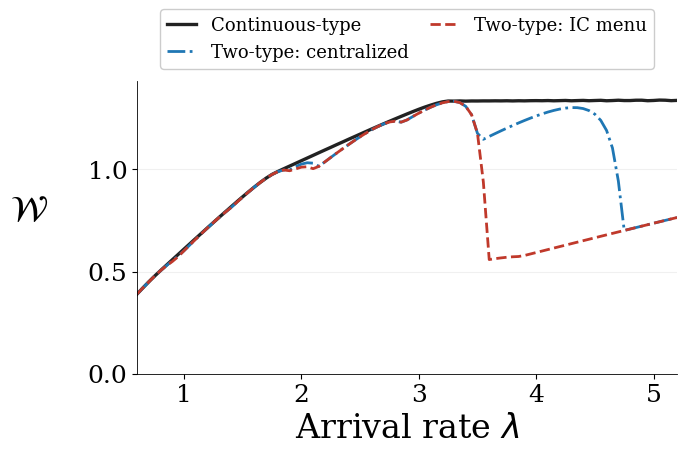

In [7]:
figure, axis = paper_axis(r'Arrival rate $\lambda$', ylabel=r'$\mathcal{W}$')
axis.plot(ARRIVALS, fine['welfare'], color='#222222', linewidth=2.4, label='Continuous-type')
axis.plot(ARRIVALS, coarse['central']['welfare'], color='#1f77b4', linestyle='-.', linewidth=2., label='Two-type: centralized')
axis.plot(ARRIVALS, coarse['ic']['welfare'], color=RED, linestyle='--', linewidth=2., label='Two-type: IC menu')
axis.set_xlim(ARRIVALS[0], ARRIVALS[-1])
axis.set_ylim(0, 1.07 * fine['welfare'].max())
paper_legend(axis, fontsize=13)
save_figure(figure, 'continuous_type_personalization_welfare')


## Service depth at the selected arrival rate

The horizontal coordinate is population quantile, so the patient cluster occupies
the left quarter. The fine design preserves service for that cluster and excludes
only the most delay-sensitive part of the impatient cluster.


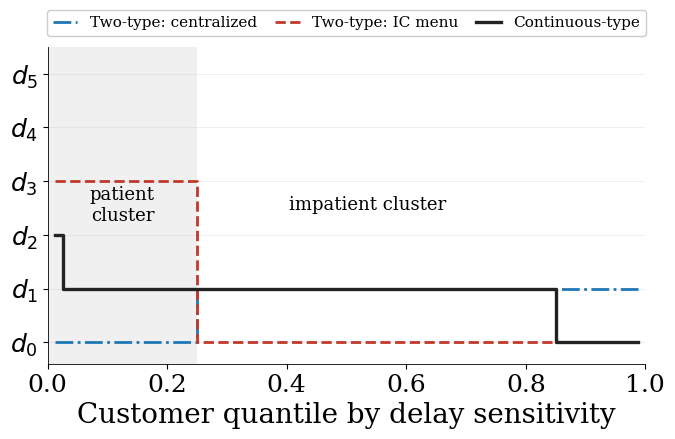

central: W=1.215358, depths=[1 0]
ic: W=0.572574, depths=[0 3]
fine: W=1.335785, patient served=100%, impatient served=80%


In [8]:
j = int(np.argmin(abs(ARRIVALS - SNAPSHOT)))
lam = ARRIVALS[j]
q = (np.arange(N) + .5) / N
series = {}
for key, label, color, linestyle in [('central', 'Two-type: centralized', '#1f77b4', '-.'),
                                      ('ic', 'Two-type: IC menu', RED, '--')]:
    d = coarse[key]['depths'][j]
    depths = np.r_[np.full(N_PATIENT, d[1]), np.full(N_IMPATIENT, d[0])]
    series[key] = (depths, dict(label=label, color=color, linestyle=linestyle, linewidth=2.))
series['fine'] = (fine['depths'][j], dict(label='Continuous-type', color='#222222', linestyle='-', linewidth=2.4))
figure, axis = paper_axis('Customer quantile by delay sensitivity', depths=True, columns=3)
axis.xaxis.label.set_size(20)
axis.axvspan(0, .25, color='#f0f0f0', linewidth=0)
axis.text(.125, .5, 'patient\ncluster', ha='center', va='center', fontsize=13, transform=axis.get_xaxis_transform())
axis.text(.535, .5, 'impatient cluster', ha='center', va='center', fontsize=13, transform=axis.get_xaxis_transform())
for depths, style in series.values(): axis.step(q, depths, where='mid', **style)
axis.set_xlim(0, 1)
paper_legend(axis, columns=3, fontsize=11)
save_figure(figure, 'continuous_type_personalization_depth')
for key in ['central', 'ic']:
    print(f"{key}: W={coarse[key]['welfare'][j]:.6f}, depths={coarse[key]['depths'][j]}")
print(f"fine: W={fine['welfare'][j]:.6f}, "
      f"patient served={np.mean(fine['depths'][j, :N_PATIENT]>0):.0%}, "
      f"impatient served={np.mean(fine['depths'][j, N_PATIENT:]>0):.0%}")
assert coarse['central']['depths'][j, 1] == 0
assert np.all(fine['depths'][j, :N_PATIENT] > 0)
assert np.any(fine['depths'][j, N_PATIENT:] == 0)
assert fine['welfare'][j] > coarse['central']['welfare'][j] > coarse['ic']['welfare'][j]


## Verification and discretization sensitivity

Check every menu option and the outside option for all 40 types, including the
expanded coarse IC menu. A local-deviation check supplements the exhaustive
monotone search. The three displayed designs personalize both depth and priority
to different degrees; the fine gain should not be attributed
solely to depth without an additional controlled comparison.


In [9]:
max_regret = max_gain = 0.
for j, lam in enumerate(ARRIVALS):
    d = fine['depths'][j]
    row = evaluate(cal, d, np.full(N, lam / N), THETA)
    assert np.isclose(row['welfare'], fine['welfare'][j], atol=1e-10)
    cert = price_certificate(cal, d, THETA, row['sojourn'])
    gain = local_deviation_gain(cal, d, lam, THETA)
    max_regret, max_gain = max(max_regret, cert['max_regret']), max(max_gain, gain)
    cd, cw = coarse['ic']['depths'][j], coarse['ic']['sojourn'][j]
    price_certificate(cal, np.r_[np.full(N_PATIENT, cd[1]), np.full(N_IMPATIENT, cd[0])],
                      THETA, np.r_[np.full(N_PATIENT, cw[1]), np.full(N_IMPATIENT, cw[0])])
assert max_gain < 1e-9
theta20 = np.r_[cluster(CENTERS[1], 5), cluster(CENTERS[0], 15)]
check_loads = np.array([1., 3., 3.8, 4.5])
grid20 = MonotoneOptimizer(cal, theta20).solve(check_loads, rules=('priority',))['priority']
for i, lam in enumerate(check_loads):
    j = int(np.argmin(abs(ARRIVALS - lam)))
    w20, w40 = grid20['welfare'][i], fine['welfare'][j]
    print(f'lambda={lam:.1f}: 20/40-type relative welfare difference={abs(w40-w20)/w40:.2%}')
print(f'Maximum IC deviation={max_regret:.2e}; single-type welfare improvement={max_gain:.2e}')


lambda=1.0: 20/40-type relative welfare difference=0.01%
lambda=3.0: 20/40-type relative welfare difference=0.00%
lambda=3.8: 20/40-type relative welfare difference=0.21%
lambda=4.5: 20/40-type relative welfare difference=0.88%
Maximum IC deviation=1.11e-16; single-type welfare improvement=0.00e+00
